# Phase 1 Baseline — long-context single-request

Single-request inference benchmark across three model types (Llama-3.1-8B-Instruct, Qwen3-8B, Qwen2-VL-7B-Instruct) at 8k / 16k / 32k / 64k context.

**Order of operations:**
3. Cells 5–8: A100 — three models, three JSONL files
4. Cell 9: one demonstrative T4 attempt to document the load-OOM finding

T4 is included only to document that 8B-class models don't fit on 16 GB GPUs finding


In [1]:
import os

REPO_URL = "https://github.com/sonavk2/LLM_Inference.git"

if not os.path.exists("results"):
    !git clone {REPO_URL}
    repo_name = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
    %cd {repo_name}

Cloning into 'LLM_Inference'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 107 (delta 46), reused 62 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 645.78 KiB | 2.81 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/LLM_Inference


In [3]:
from huggingface_hub import login
login()


In [4]:
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen3_8b.yaml \
  --context-lengths 1024 --max-new-tokens 32 \
  --results-path results/dryrun.jsonl

import json
for line in open('results/dryrun.jsonl'):
    r = json.loads(line)
    print(f"{r['model_name']}: success={r['success']} "
          f"ttft={r['ttft_seconds']:.3f}s total={r['total_latency_seconds']:.3f}s "
          f"peak={r['peak_gpu_memory_gb']:.2f} GB")


Loading Qwen/Qwen3-8B (dtype=bfloat16, quant=none) on cuda ...
config.json: 100% 728/728 [00:00<00:00, 3.42MB/s]
tokenizer_config.json: 9.73kB [00:00, 13.7MB/s]
vocab.json: 2.78MB [00:00, 10.6MB/s]
merges.txt: 1.67MB [00:00, 11.2MB/s]
tokenizer.json: 100% 11.4M/11.4M [00:00<00:00, 13.8MB/s]
model.safetensors.index.json: 32.9kB [00:00, 63.3MB/s]
Fetching 5 files: 100% 5/5 [00:42<00:00,  8.50s/it]
Download complete: 100% 16.4G/16.4G [00:42<00:00, 385MB/s]
Loading weights: 100% 399/399 [00:00<00:00, 923.57it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 239/239 [00:00<00:00, 1.21MB/s]
Model loaded.

--- context_length=1024, batch_size=1, native=True ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Pleas

## A100 sweeps

Three models, four context lengths each. Each cell writes one JSONL file. ~10–20 min per cell on A100.


In [5]:
# 4. Llama-3.1-8B-Instruct on A100.
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/llama3_1_8b_instruct.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --results-path results/phase1_llama31_a100.jsonl


Loading meta-llama/Meta-Llama-3.1-8B-Instruct (dtype=bfloat16, quant=none) on cuda ...
config.json: 100% 855/855 [00:00<00:00, 4.02MB/s]
tokenizer_config.json: 55.4kB [00:00, 50.1MB/s]
tokenizer.json: 9.09MB [00:00, 29.7MB/s]
special_tokens_map.json: 100% 296/296 [00:00<00:00, 1.66MB/s]
model.safetensors.index.json: 23.9kB [00:00, 47.1MB/s]
Fetching 4 files: 100% 4/4 [00:41<00:00, 10.28s/it]
Download complete: 100% 16.1G/16.1G [00:41<00:00, 390MB/s]
Loading weights: 100% 291/291 [00:00<00:00, 1067.19it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 184/184 [00:00<00:00, 856kB/s]
Model loaded.

--- context_length=8192, batch_size=1, native=True ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your i

In [6]:
# 5. Qwen3-8B (reasoning architecture) on A100
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen3_8b.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --results-path results/phase1_qwen3_a100.jsonl


Loading Qwen/Qwen3-8B (dtype=bfloat16, quant=none) on cuda ...
Loading weights: 100% 399/399 [00:00<00:00, 1003.73it/s, Materializing param=model.norm.weight]
Model loaded.

--- context_length=8192, batch_size=1, native=True ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
  success=True ttft=1.2385700759999736 latency=7.366264139000009 peak_gpu_gb=18.477005824 kv_cache_gb=1.2080

--- context_length=16384, batch_size=1, native=True ---
  success=True ttft=1.6018274120000342 latency=7.706937841000013 peak_gpu_gb=20.561902592 kv_cache_gb=2.4159

--- context_length=32768, batch_size=1, native=True ---
  success=True ttft=3.934611115999928 latency=9.9499965989

In [7]:
# 6. Qwen2-VL-7B-Instruct (vision-language) on A100
!python3 scripts/run_vlm_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen2_vl_7b.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --results-path results/phase1_qwen2vl_a100.jsonl


Loading VLM Qwen/Qwen2-VL-7B-Instruct (dtype=bfloat16) on cuda ...
preprocessor_config.json: 100% 347/347 [00:00<00:00, 1.54MB/s]
chat_template.json: 1.05kB [00:00, 2.81MB/s]
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
config.json: 1.20kB [00:00, 3.12MB/s]
tokenizer_config.json: 4.19kB [00:00, 11.1MB/s]
vocab.json: 2.78MB [00:00, 11.5MB/s]
merges.txt: 1.67MB [00:00, 9.08MB/s]
tokenizer.json: 7.03MB [00:00, 17.5MB/s]
model.safetensors.index.json: 56.5kB [00:00, 97.4MB/s]
Fetching 5 files: 100% 5/5 [00:43<00:00,  8.60s/it]
Download complete: 100% 16.6G/16.6G [00:43<00:00, 385MB/s]
Loading weights: 100% 730/730 [00:00<00:00, 760.49it/s, Materializing param=model.visual.patch_embed.proj.weight]
generation_config.json: 100% 

## T4 — single demonstrative attempt

Run *once* on a T4 runtime to document that 8B-class bf16 weights don't fit on a 16 GB GPU. The script will fail at `model.to('cuda')` before any context-length cell runs, so we record the finding manually.

Skip this section entirely if you're only running on A100.


In [4]:
# 7. T4 attempt
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen3_8b.yaml \
  --context-lengths 8192 \
  --max-new-tokens 32 \
  --results-path results/phase1_qwen3_t4.jsonl 2>&1 | tail -25

import json
err = ('CUDA OOM at model load: bf16 weights ~14.1 GB exceed T4 free memory '
       '(14.56 GB total, ~225 MB free at failure). Qwen3-8B in bf16 cannot '
       'load on T4; the same applies to Llama-3.1-8B and Qwen2-VL-7B (all '
       '~16 GB weights).')
with open('results/phase1_qwen3_t4.jsonl', 'w') as f:
    for ctx in [8192, 16384, 32768, 65536]:
        f.write(json.dumps({
            'model_name': 'Qwen/Qwen3-8B', 'backend': 'huggingface',
            'hardware': 'cuda:Tesla T4',
            'context_length': ctx, 'batch_size': 1, 'max_new_tokens': 128,
            'ttft_seconds': None, 'tpot_seconds': None,
            'total_latency_seconds': None, 'tokens_per_second': None,
            'peak_gpu_memory_gb': 14.10, 'kv_cache_memory_gb': None,
            'success': False, 'error': err,
            'prompt_format': 'synthetic_repeat',
            'is_native_context': ctx <= 32768,
            'image_token_count': None, 'text_token_count': None,
            'quantization': None,
        }) + '\n')
print('T4 finding recorded as 4 load-OOM rows in phase1_qwen3_t4.jsonl')



^C
T4 finding recorded as 4 load-OOM rows in phase1_qwen3_t4.jsonl


## Visualizations

Loads every `results/phase1_*.jsonl` and produces:
- One 2×3 figure per hardware (TTFT, TPOT, throughput, total latency, peak memory, KV-cache estimate)
- Memory-frontier matrix per hardware (model × context, green=OK, red=OOM)

PNGs saved to `results/plots/`.


In [8]:
import json, glob
from pathlib import Path
import pandas as pd

rows = []
for path in sorted(glob.glob('results/phase1_*.jsonl')):
    for line in open(path):
        r = json.loads(line)
        r['_source'] = Path(path).name
        rows.append(r)
if not rows:
    raise SystemExit('No results/phase1_*.jsonl files found yet.')

df = pd.DataFrame(rows)

def label_for(row):
    m = row['model_name']
    if 'Llama-3.1' in m:    return 'Llama-3.1-8B-Inst'
    if 'Qwen3' in m:        return 'Qwen3-8B'
    if 'Qwen2-VL' in m:     return 'Qwen2-VL-7B-Inst'
    return m
df['label'] = df.apply(label_for, axis=1)

print(f'loaded {len(df)} rows from {df["_source"].nunique()} files')
print(df[['label', 'hardware', 'context_length', 'success',
          'ttft_seconds', 'total_latency_seconds',
          'peak_gpu_memory_gb', 'kv_cache_memory_gb']]
      .sort_values(['hardware', 'label', 'context_length'])
      .to_string(index=False))


loaded 12 rows from 3 files
            label                   hardware  context_length  success  ttft_seconds  total_latency_seconds  peak_gpu_memory_gb  kv_cache_memory_gb
Llama-3.1-8B-Inst cuda:NVIDIA A100-SXM4-40GB            8192     True      1.138771               5.345978           18.120388            1.073742
Llama-3.1-8B-Inst cuda:NVIDIA A100-SXM4-40GB           16384     True      1.453901               5.590028           20.171730            2.147484
Llama-3.1-8B-Inst cuda:NVIDIA A100-SXM4-40GB           32768     True      3.568209               7.662159           24.274415            4.294967
Llama-3.1-8B-Inst cuda:NVIDIA A100-SXM4-40GB           65536     True      9.787405              14.631455           32.479784            8.589935
 Qwen2-VL-7B-Inst cuda:NVIDIA A100-SXM4-40GB            8192     True      2.862264               3.253800           18.289264            0.469762
 Qwen2-VL-7B-Inst cuda:NVIDIA A100-SXM4-40GB           16384     True      1.316750       

saved results/plots/phase1_cuda_NVIDIA_A100-SXM4-40GB.png


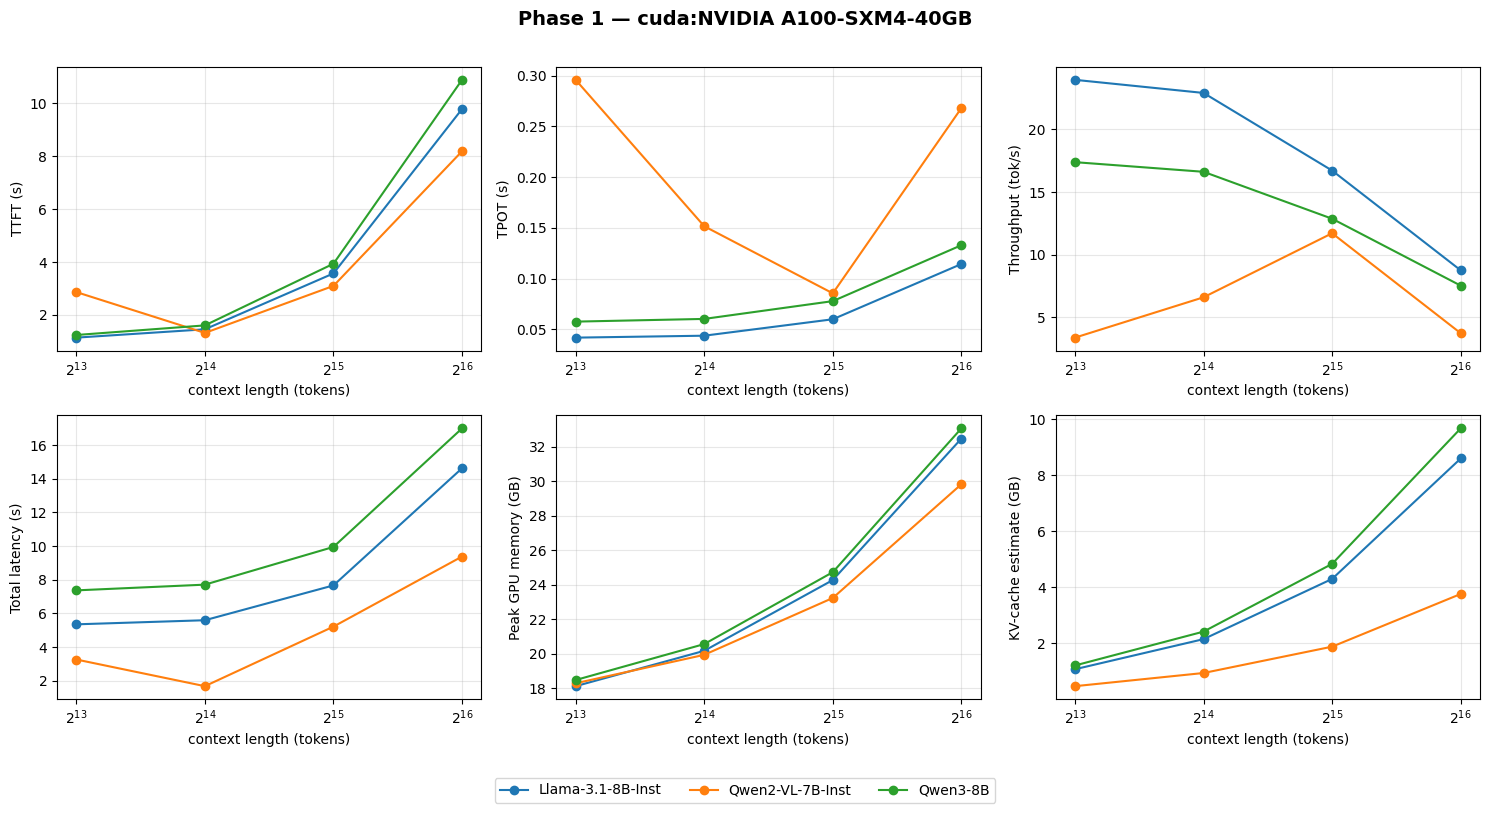

In [9]:
import matplotlib.pyplot as plt

PLOT_DIR = Path('results/plots'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
METRICS = [
    ('ttft_seconds',          'TTFT (s)'),
    ('tpot_seconds',          'TPOT (s)'),
    ('tokens_per_second',     'Throughput (tok/s)'),
    ('total_latency_seconds', 'Total latency (s)'),
    ('peak_gpu_memory_gb',    'Peak GPU memory (GB)'),
    ('kv_cache_memory_gb',    'KV-cache estimate (GB)'),
]

for hw, sub in df.groupby('hardware'):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'Phase 1 — {hw}', fontsize=14, fontweight='bold')
    for (col, ylabel), ax in zip(METRICS, axes.flat):
        for label, grp in sub.groupby('label'):
            ok   = grp[grp.success == True ].sort_values('context_length')
            fail = grp[grp.success == False].sort_values('context_length')
            ax.plot(ok.context_length, ok[col], marker='o', label=label)
            if len(fail):
                y = fail[col].fillna(0) if col in ('peak_gpu_memory_gb','kv_cache_memory_gb') else [0]*len(fail)
                ax.scatter(fail.context_length, y, marker='x', color='red', s=120, zorder=5, linewidths=2.5)
        ax.set_xscale('log', base=2)
        ax.set_xlabel('context length (tokens)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=(0, 0.04, 1, 0.97))
    safe_hw = hw.replace(':', '_').replace(' ', '_').replace('/', '_')
    out = PLOT_DIR / f'phase1_{safe_hw}.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'saved {out}')
    plt.show()


saved results/plots/frontier_cuda_NVIDIA_A100-SXM4-40GB.png


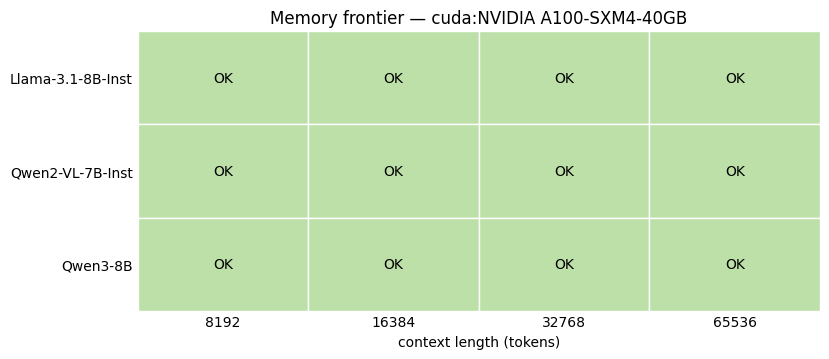

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

for hw, sub in df.groupby('hardware'):
    pivot_ok = sub.pivot_table(index='label', columns='context_length',
                               values='success', aggfunc='first')
    if pivot_ok.empty: continue
    fig, ax = plt.subplots(figsize=(1.6 * len(pivot_ok.columns) + 2, 0.9 * len(pivot_ok.index) + 1))
    for i, model in enumerate(pivot_ok.index):
        for j, ctx in enumerate(pivot_ok.columns):
            v = pivot_ok.loc[model, ctx]
            color = '#bde0a8' if v == True else ('#f4a8a8' if v == False else '#dddddd')
            ax.add_patch(Rectangle((j, i), 1, 1, facecolor=color, edgecolor='white'))
            label = 'OK' if v == True else ('OOM' if v == False else '-')
            ax.text(j + 0.5, i + 0.5, label, ha='center', va='center', fontsize=10)
    ax.set_xlim(0, len(pivot_ok.columns)); ax.set_ylim(0, len(pivot_ok.index))
    ax.invert_yaxis()
    ax.set_xticks(np.arange(len(pivot_ok.columns)) + 0.5); ax.set_xticklabels(pivot_ok.columns)
    ax.set_yticks(np.arange(len(pivot_ok.index)) + 0.5);   ax.set_yticklabels(pivot_ok.index)
    ax.set_xlabel('context length (tokens)')
    ax.set_title(f'Memory frontier — {hw}')
    ax.tick_params(length=0)
    for spine in ax.spines.values(): spine.set_visible(False)
    plt.tight_layout()
    safe_hw = hw.replace(':', '_').replace(' ', '_').replace('/', '_')
    out = Path('results/plots') / f'frontier_{safe_hw}.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'saved {out}')
    plt.show()
